# Assignment 18 - Text Vectorization Techniques

## Objective

In this assignment, I explored different techniques used to convert text into numerical features that machine learning algorithms can understand.

The focus of this assignment is feature extraction only, so no machine learning models are trained. I implemented and compared:

- Manual One-Hot Encoding
- One-Hot Encoding using CountVectorizer
- Bag of Words (BoW)
- N-Grams
- TF-IDF Vectorization

Throughout the notebook, I compare how each technique represents text and discuss the advantages and limitations of each method.

---

## Dataset

**Dataset:** SMS Spam Collection Dataset

**Source:** Kaggle

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

For consistency, I am using the same cleaned dataset that I created in Assignment 17. The `final_clean_text` column generated in the previous assignment will be used for all vectorization tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df=pd.read_csv("spam.csv",encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df=df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.columns=["label","text"]
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
import re

In [6]:
def remove_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

In [7]:
slang_dict = {
    "u": "you",
    "ur": "your",
    "pls": "please",
    "msg": "message",
    "luv": "love",
    "thx": "thanks",
    "thanx": "thanks",
    "tmr": "tomorrow",
    "gr8": "great",
    "wat": "what",
    "wif": "with",
    "gud": "good",
    "nite": "night",
    "coz": "because",
    "c": "see",
    "txt": "text",
    "wk": "week",
    "wkly": "weekly",
    "mins": "minutes",
    "ya": "yeah",
    "yae": "yeah",
    "lor": "lord",
    "da": "the",
    "oso": "also"
}

In [8]:
def replace_slang(text):
    words = text.split()
    updated_words = []
    for word in words:
        if word in slang_dict:
            updated_words.append(slang_dict[word])
        else:
            updated_words.append(word)
    return " ".join(updated_words)

In [13]:
import nltk
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [14]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)
    return ' '.join(filtered_words)

In [9]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [11]:
from nltk.tokenize import word_tokenize
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

In [15]:
def nlp_preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_repeated_characters(text)
    text = replace_slang(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [16]:
df["final_clean_text"] = df["text"].apply(nlp_preprocess)

In [19]:
df.shape
df.info()
df[["label", "text", "final_clean_text"]].head()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   label             5572 non-null   str  
 1   text              5572 non-null   str  
 2   final_clean_text  5572 non-null   str  
dtypes: str(3)
memory usage: 855.4 KB


,label,text,final_clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts s...
3,ham,U dun say so early hor... U c already then say...,dun say early hor see already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [20]:
df.isnull().sum()

label               0
text                0
final_clean_text    0
dtype: int64

In [22]:
df['final_clean_text'].sample(5)

1236                                         much getting
2095                                   probably want pick
3774    hi spoke maneesha v wed like know satisfied ex...
4049                           ok ok take care understand
1163    new theory argument win situation loses person...
Name: final_clean_text, dtype: str

## Initial Observations

Before applying vectorization, I checked the cleaned text generated in the previous assignment. The messages are already lowercased, punctuation has been removed, stopwords have been filtered out, and the text has been lemmatized. This allows the vectorizers to focus on meaningful words instead of unnecessary noise.

# Part 1 - One-Hot Encoding

One-Hot Encoding represents each unique word as a binary feature. A value of **1** means the word is present in a sentence, while **0** means it is is absent.

To understand how it works, I first implemented One-Hot Encoding manually before using Scikit-learn.

## Task-1

In [25]:
sample_sentences = df["final_clean_text"].head(5)

for i, sentence in enumerate(sample_sentences):
    print(f"Sentence {i+1}:")
    print(sentence)
    print()

Sentence 1:
go jurong point crazy available bugis n great world la e buffet cine got amore

Sentence 2:
ok lar joking oni

Sentence 3:
free entry weekly comp win fa cup final tkts st may text fa receive entry questionstd text ratetcs apply over

Sentence 4:
dun say early hor see already say

Sentence 5:
nah dont think go usf life around though



In [26]:
vocabulary = []
for sentence in sample_sentences:
    words = sentence.split()
    for word in words:
        if word not in vocabulary:
            vocabulary.append(word)

print("Vocabulary Size:", len(vocabulary))
print(vocabulary)

Vocabulary Size: 49
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'ok', 'lar', 'joking', 'oni', 'free', 'entry', 'weekly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'receive', 'questionstd', 'ratetcs', 'apply', 'over', 'dun', 'say', 'early', 'hor', 'see', 'already', 'nah', 'dont', 'think', 'usf', 'life', 'around', 'though']


In [27]:
encoded_vectors=[]
for sentence in sample_sentences:
    words = sentence.split()
    vector = []
    for vocab_word in vocabulary:
        if vocab_word in words:
            vector.append(1)
        else:
            vector.append(0)
    encoded_vectors.append(vector)

In [28]:
one_hot_df=pd.DataFrame(encoded_vectors, columns=vocabulary)
one_hot_df.index = [f"Sentence {i+1}" for i in range(len(one_hot_df))]
one_hot_df

,go,jurong,point,crazy,available,bugis,n,great,world,la,e,buffet,cine,got,amore,ok,lar,joking,oni,free,entry,weekly,comp,win,fa,cup,final,tkts,st,may,text,receive,questionstd,ratetcs,apply,over,dun,say,early,hor,see,already,nah,dont,think,usf,life,around,though
Sentence 1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sentence 2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sentence 3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Sentence 4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0
Sentence 5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1


### Observations

After selecting the first five cleaned messages, I manually created a vocabulary containing **49 unique words**. Each sentence was then represented as a binary vector where:

- **1** indicates that the word is present in the sentence.
- **0** indicates that the word is absent.

While creating the vectors manually helped me understand how One-Hot Encoding works internally, I also noticed that the number of columns grows quickly as the vocabulary increases. Even with only five messages, the encoding already required 49 different features.

## Task 2 - One-Hot Encoding using Scikit-learn

After implementing One-Hot Encoding manually, I used Scikit-learn's `CountVectorizer` with `binary=True`. This produces the same binary representation while automatically building the vocabulary and encoding the sentences.

In [29]:
vectorizer = CountVectorizer(binary=True)
one_hot_matrix = vectorizer.fit_transform(sample_sentences)

In [30]:
vocabulary = vectorizer.get_feature_names_out()
print("Vocabulary Size:", len(vocabulary))
print(vocabulary)

Vocabulary Size: 47
['already' 'amore' 'apply' 'around' 'available' 'buffet' 'bugis' 'cine'
 'comp' 'crazy' 'cup' 'dont' 'dun' 'early' 'entry' 'fa' 'final' 'free'
 'go' 'got' 'great' 'hor' 'joking' 'jurong' 'la' 'lar' 'life' 'may' 'nah'
 'ok' 'oni' 'over' 'point' 'questionstd' 'ratetcs' 'receive' 'say' 'see'
 'st' 'text' 'think' 'though' 'tkts' 'usf' 'weekly' 'win' 'world']


In [31]:
one_hot_sklearn = pd.DataFrame(
    one_hot_matrix.toarray(),
    columns=vocabulary,
    index=[f"Sentence {i+1}" for i in range(len(sample_sentences))]
)

one_hot_sklearn

,already,amore,apply,around,available,buffet,bugis,cine,comp,crazy,cup,dont,dun,early,entry,fa,final,free,go,got,great,hor,joking,jurong,la,lar,life,may,nah,ok,oni,over,point,questionstd,ratetcs,receive,say,see,st,text,think,though,tkts,usf,weekly,win,world
Sentence 1,0,1,0,0,1,1,1,1,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
Sentence 2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sentence 3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0,1,1,0,0,1,0,1,1,0
Sentence 4,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
Sentence 5,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0


In [32]:
print("Manual Shape :", one_hot_df.shape)
print("Scikit-learn Shape :", one_hot_sklearn.shape)

Manual Shape : (5, 49)
Scikit-learn Shape : (5, 47)


### Observations

The Scikit-learn implementation produced a vocabulary of **47 words**, while my manual implementation produced **49 words**.

The difference occurred because `CountVectorizer` ignores single-character tokens by default. In my manually created vocabulary, words like **"n"** and **"e"** were included, but Scikit-learn automatically removed them using its default tokenization rules.

Although the vocabulary sizes are slightly different, both methods follow the same basic idea of One-Hot Encoding by representing each sentence as a binary vector indicating the presence or absence of each word.

Using Scikit-learn is much faster and more practical, especially for larger datasets where creating the vectors manually would not be efficient.

# Part 2 - Bag of Words (BoW)

Unlike One-Hot Encoding, Bag of Words stores the frequency of each word instead of only indicating whether the word exists or not. This provides more information about how often words appear in each document.

In [35]:
bow = CountVectorizer()
bow_matrix = bow.fit_transform(df["final_clean_text"])

In [36]:
print("Vocabulary Size:", len(bow.vocabulary_))
print("BOW Matrix Shape:", bow_matrix.shape)

Vocabulary Size: 7805
BOW Matrix Shape: (5572, 7805)


In [37]:
vocabulary = bow.get_feature_names_out()
print("First 30 words in the vocabulary:", vocabulary[:30])

First 30 words in the vocabulary: ['__' 'aa' 'aah' 'aaniye' 'aaooright' 'aathilove' 'aathiwhere' 'ab'
 'abbey' 'abdomen' 'abeg' 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj'
 'able' 'abnormally' 'aboutas' 'abroad' 'absence' 'absolutely' 'abstract'
 'abt' 'abta' 'aburo' 'abuse' 'abuser' 'ac']


In [38]:
bow_df = pd.DataFrame(
    bow_matrix[:5].toarray(),
    columns=vocabulary
)

bow_df.iloc[:, :20]

,__,aa,aah,aaniye,aaooright,aathilove,aathiwhere,ab,abbey,abdomen,abeg,abel,aberdeen,abi,ability,abiola,abj,able,abnormally,aboutas
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Observation

This time I fitted CountVectorizer on the entire dataset instead of only a few sample messages.

The vocabulary became much larger because it now includes unique words from all 5,572 SMS messages. Each row represents one SMS, while each column represents a word from the vocabulary. The values indicate how many times each word appears in a message.

Compared to One-Hot Encoding, Bag of Words stores word frequencies instead of only indicating whether a word is present.

# Task 4 - Word Frequency Analysis

After creating the Bag of Words representation, I explored the vocabulary to understand which words appear most frequently in the SMS dataset.

This analysis helps identify common words in the corpus and gives a better understanding of the dataset before applying machine learning models.

In [39]:
word_frequencies = bow_matrix.sum(axis=0)
frequency_df = pd.DataFrame({
    "Word": vocabulary,
    "Frequency": np.array(word_frequencies).flatten()
})
frequency_df.head()

,Word,Frequency
0,__,2
1,aa,1
2,aah,3
3,aaniye,1
4,aaooright,1


In [40]:
top_words=frequency_df.sort_values(by="Frequency", ascending=False).head(10)
top_words

,Word,Frequency
933,call,602
3164,im,464
2595,get,401
6688,text,378
2643,go,308
2671,good,288
1841,dont,279
2450,free,278
4643,ok,277
3893,ltgt,276


In [41]:
least_words=frequency_df.sort_values(by="Frequency", ascending=True).head(10)
least_words

,Word,Frequency
7792,åòharry,1
7793,åòits,1
7794,åômorrow,1
7795,åôrents,1
7801,û_thanks,1
1,aa,1
3,aaniye,1
4,aaooright,1
7,ab,1
8,abbey,1


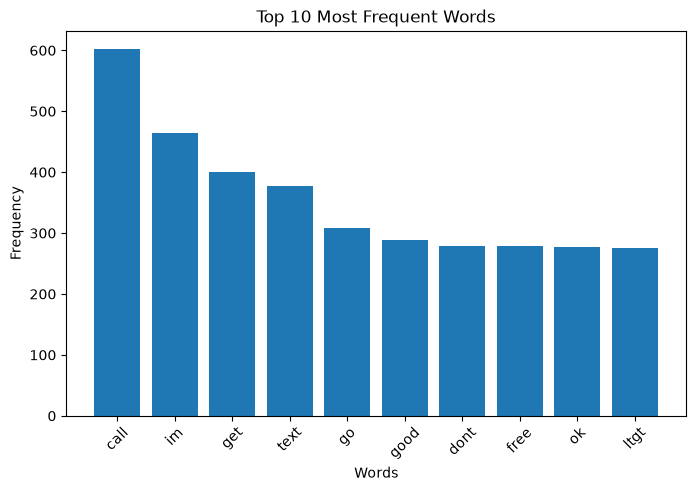

In [42]:
plt.figure(figsize=(8,5))
plt.bar(top_words["Word"],top_words["Frequency"])
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [43]:
frequency_df["Frequency"].describe()

count    7805.000000
mean        6.010890
std        21.014438
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       602.000000
Name: Frequency, dtype: float64

### Observations

- The vocabulary contains **7,805 unique words** after preprocessing.
- Words such as **call**, **im**, **get**, **text**, and **good** are among the most frequent terms in the dataset. These words commonly appear in everyday SMS conversations.
- Many words have a frequency of **1**, which means they appear in only a single message. This indicates that the dataset has a large number of unique or rare words.
- The average word frequency is approximately **6**, but the median frequency is only **1**, showing that the distribution is highly skewed. A small number of words occur very frequently, while most words appear only once or twice.
- This analysis shows why text datasets usually have large and sparse vocabularies, which is an important consideration when building NLP models.

# Task 5 - N-Grams

A Bag of Words model treats every word independently and ignores the order in which words appear.

To preserve some context, I used **N-Grams**, where:
- **Unigrams** represent single words.
- **Bigrams** represent pairs of consecutive words.
- **Trigrams** represent groups of three consecutive words.

In [44]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vectorizer.fit_transform(df["final_clean_text"])
print("Bigram Vocabulary Size:", len(bigram_vectorizer.vocabulary_))
print("Bigram Matrix Shape:", bigram_matrix.shape)

Bigram Vocabulary Size: 29730
Bigram Matrix Shape: (5572, 29730)


In [45]:
bigram_features = bigram_vectorizer.get_feature_names_out()
print("First 20 Bigrams:\n")
for gram in bigram_features[:20]:
    print(gram)

First 20 Bigrams:

__ joy
aa exhaust
aah bless
aah cuddle
aah speak
aaniye pudunga
aaooright work
aathilove lot
aathiwhere dear
ab sara
abbey happy
abdomen gynae
abeg make
aberdeen united
abi hwkeep
abi saying
ability listen
ability question
abj serving
able anything


In [46]:
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))
trigram_matrix = trigram_vectorizer.fit_transform(df["final_clean_text"])
print("Trigram Vocabulary Size:", len(trigram_vectorizer.vocabulary_))
print("Trigram Matrix Shape:", trigram_matrix.shape)

Trigram Vocabulary Size: 29693
Trigram Matrix Shape: (5572, 29693)


In [47]:
trigram_features = trigram_vectorizer.get_feature_names_out()
print("First 20 Trigrams:\n")
for gram in trigram_features[:20]:
    print(gram)

First 20 Trigrams:

__ joy father
aa exhaust hanging
aah bless hows
aah cuddle would
aah speak tomo
aaniye pudunga venaam
ab sara jorgeshock
abbey happy new
abdomen gynae infection
abeg make profit
aberdeen united kingdom
abi hwkeep posted
abi saying hi
ability listen anything
abj serving staying
able atten class
able buy liquor
able come office
able deliver basic
able dont know


In [48]:
comparison = pd.DataFrame({
    "Representation": [
        "Unigrams (BoW)",
        "Bigrams",
        "Trigrams"
    ],
    "Vocabulary Size": [
        len(bow.vocabulary_),
        len(bigram_vectorizer.vocabulary_),
        len(trigram_vectorizer.vocabulary_)
    ]
})

comparison

,Representation,Vocabulary Size
0,Unigrams (BoW),7805
1,Bigrams,29730
2,Trigrams,29693


In [49]:
sample_text = df.loc[0, "final_clean_text"]
print("Sample Message:\n")
print(sample_text)
print("\nGenerated Bigrams:\n")
from nltk.util import ngrams
tokens = sample_text.split()
for gram in ngrams(tokens, 2):
    print(gram)

Sample Message:

go jurong point crazy available bugis n great world la e buffet cine got amore

Generated Bigrams:

('go', 'jurong')
('jurong', 'point')
('point', 'crazy')
('crazy', 'available')
('available', 'bugis')
('bugis', 'n')
('n', 'great')
('great', 'world')
('world', 'la')
('la', 'e')
('e', 'buffet')
('buffet', 'cine')
('cine', 'got')
('got', 'amore')


# Task 6 - Comparing Unigrams, Bigrams and Trigrams

In [51]:
comparison_df = pd.DataFrame({
    "Representation": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "Vocabulary Size": [
        len(bow.vocabulary_),
        len(bigram_vectorizer.vocabulary_),
        len(trigram_vectorizer.vocabulary_)
    ],
    "Matrix Shape": [
        bow_matrix.shape,
        bigram_matrix.shape,
        trigram_matrix.shape
    ]
})

comparison_df

,Representation,Vocabulary Size,Matrix Shape
0,Unigram,7805,"(5572, 7805)"
1,Bigram,29730,"(5572, 29730)"
2,Trigram,29693,"(5572, 29693)"


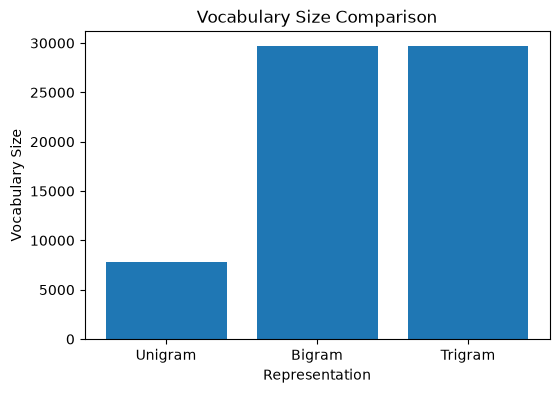

In [52]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison_df["Representation"],
    comparison_df["Vocabulary Size"]
)

plt.title("Vocabulary Size Comparison")
plt.xlabel("Representation")
plt.ylabel("Vocabulary Size")

plt.show()

### Observations

- Unigrams produce the smallest vocabulary because each feature represents a single word.
- Bigrams and trigrams capture more context by considering sequences of words instead of individual words.
- The vocabulary size increased from **7,805** for unigrams to nearly **30,000** for bigrams and trigrams.
- While higher-order n-grams preserve more context, they also create a much larger and sparser feature space.
- Choosing the appropriate n-gram depends on the NLP task and the available computational resources.

# Part-4

# Task 7 - TF-IDF (Term Frequency - Inverse Document Frequency)

Bag of Words represents text using the frequency of words, but it gives equal importance to all words.

TF-IDF improves this representation by assigning higher weights to words that are important in a particular document and lower weights to words that appear very frequently across the entire dataset.

In this task, I generated TF-IDF vectors for the cleaned SMS messages and explored the resulting feature matrix.

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["final_clean_text"])
print("TF-IDF Vocabulary Size:", len(tfidf.vocabulary_))
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Vocabulary Size: 7805
TF-IDF Matrix Shape: (5572, 7805)


In [56]:
tfidf_features = tfidf.get_feature_names_out()
print("First 20 TF-IDF Features:\n")
print(tfidf_features[:20])

First 20 TF-IDF Features:

['__' 'aa' 'aah' 'aaniye' 'aaooright' 'aathilove' 'aathiwhere' 'ab'
 'abbey' 'abdomen' 'abeg' 'abel' 'aberdeen' 'abi' 'ability' 'abiola' 'abj'
 'able' 'abnormally' 'aboutas']


In [57]:
tfidf_df = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=tfidf_features
)

tfidf_df.iloc[:, :20]

,__,aa,aah,aaniye,aaooright,aathilove,aathiwhere,ab,abbey,abdomen,abeg,abel,aberdeen,abi,ability,abiola,abj,able,abnormally,aboutas
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
sample_index = 0

sample_vector = pd.DataFrame({
    "Word": tfidf_features,
    "TF-IDF Score": tfidf_matrix[sample_index].toarray().flatten()
})

sample_vector = sample_vector[sample_vector["TF-IDF Score"] > 0]

sample_vector = sample_vector.sort_values(
    by="TF-IDF Score",
    ascending=False
)

sample_vector.head(10)

,Word,TF-IDF Score
232,amore,0.357179
3466,jurong,0.357179
876,buffet,0.340966
1183,cine,0.301746
878,bugis,0.301746
3610,la,0.292824
1446,crazy,0.276611
460,available,0.271606
5048,point,0.243889
7581,world,0.242730


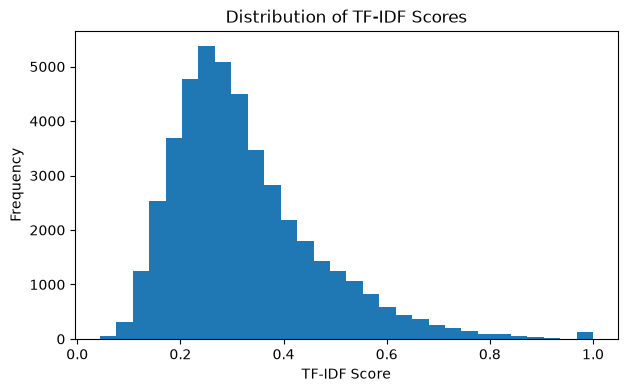

In [59]:
non_zero_scores = tfidf_matrix.data
plt.figure(figsize=(7,4))
plt.hist(non_zero_scores, bins=30)
plt.title("Distribution of TF-IDF Scores")
plt.xlabel("TF-IDF Score")
plt.ylabel("Frequency")
plt.show()

### Observations

- The TF-IDF vocabulary contains **7,805 unique words**, which is the same size as the Bag of Words vocabulary because both methods use the same corpus.
- Unlike Bag of Words, TF-IDF assigns weights instead of simple word counts.
- In the first SMS message, words such as **"amore"**, **"jurong"**, and **"buffet"** received the highest TF-IDF scores because they are relatively unique and provide more information about that message.
- The histogram shows that most TF-IDF scores are relatively small, while only a few words receive very high weights. This indicates that TF-IDF highlights important words and reduces the influence of common words.

# Task 8 - Bag of Words vs TF-IDF

Both Bag of Words and TF-IDF convert text into numerical features, but they represent the importance of words differently.

In this task, I compared the two methods to understand how TF-IDF changes the representation of common and informative words.

In [61]:
comparison_df = pd.DataFrame({
    "Feature": [
        "Vocabulary Size",
        "Matrix Shape",
        "Output Values",
        "Common Words"
    ],
    "Bag of Words": [
        len(bow.vocabulary_),
        str(bow_matrix.shape),
        "Word Counts",
        "High Frequency"
    ],
    "TF-IDF": [
        len(tfidf.vocabulary_),
        str(tfidf_matrix.shape),
        "Weighted Scores",
        "Lower Weight"
    ]
})

comparison_df

,Feature,Bag of Words,TF-IDF
0,Vocabulary Size,7805,7805
1,Matrix Shape,"(5572, 7805)","(5572, 7805)"
2,Output Values,Word Counts,Weighted Scores
3,Common Words,High Frequency,Lower Weight


In [62]:
common_words = ["call", "text", "free", "good", "go"]

comparison = []

for word in common_words:
    if word in tfidf.vocabulary_:
        idx = tfidf.vocabulary_[word]

        comparison.append({
            "Word": word,
            "BoW Frequency": int(bow_matrix[:, idx].sum()),
            "Average TF-IDF": round(tfidf_matrix[:, idx].mean(), 4)
        })

comparison = pd.DataFrame(comparison)

comparison

,Word,BoW Frequency,Average TF-IDF
0,call,602,0.0214
1,text,378,0.0116
2,free,278,0.0093
3,good,288,0.0112
4,go,308,0.0110


In [64]:
tfidf_scores = tfidf_matrix.mean(axis=0).A1

low_tfidf = pd.DataFrame({
    "Word": tfidf.get_feature_names_out(),
    "Average TF-IDF": tfidf_scores
})

low_tfidf = low_tfidf.sort_values(
    by="Average TF-IDF",
    ascending=True
).head(10)

low_tfidf

,Word,Average TF-IDF
2274,festival,0.000017
2483,friendshipmotherfatherteacherschildrens,0.000017
5933,shivratri,0.000017
5494,rememberi,0.000017
5716,sankranti,0.000017
5528,republic,0.000017
6745,theseyours,0.000017
1564,dasara,0.000017
3209,independence,0.000017
7052,ugadi,0.000017


### Why do common words have low TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency) assigns lower weights to words that appear in many documents.

For example, words like **"call"**, **"text"**, and **"go"** occur in hundreds of SMS messages. Although these words have high frequencies, they do not help distinguish one message from another.

On the other hand, unique words such as **"jurong"**, **"amore"**, and **"buffet"** appear in very few messages, making them more informative. Therefore, TF-IDF assigns them higher weights.

This property makes TF-IDF more effective than Bag of Words for many NLP tasks because it emphasizes meaningful words while reducing the influence of very common words.


# Part-5

# Task 9 - Vectorizer Parameter Exploration

In this task, I experimented with different parameters of `CountVectorizer` to observe how the vocabulary size changes.

The parameters explored are:

- `max_features`
- `min_df`
- `max_df`

These parameters are useful for reducing vocabulary size, removing rare words, and filtering overly common words.

In [65]:
from sklearn.feature_extraction.text import CountVectorizer

max_features_values = [500, 1000, 3000, 5000, None]
max_results = []
for value in max_features_values:
    vectorizer = CountVectorizer(max_features=value)
    vectorizer.fit(df["final_clean_text"])
    max_results.append({
        "max_features": value if value is not None else "All",
        "Vocabulary Size": len(vectorizer.vocabulary_)
    })
max_features_df = pd.DataFrame(max_results)
max_features_df

,max_features,Vocabulary Size
0,500,500
1,1000,1000
2,3000,3000
3,5000,5000
4,All,7805


In [66]:
min_df_values = [1, 2, 5, 10]
min_results = []
for value in min_df_values:
    vectorizer = CountVectorizer(min_df=value)
    vectorizer.fit(df["final_clean_text"])
    min_results.append({
        "min_df": value,
        "Vocabulary Size": len(vectorizer.vocabulary_)
    })
min_df_df = pd.DataFrame(min_results)
min_df_df

,min_df,Vocabulary Size
0,1,7805
1,2,3502
2,5,1509
3,10,822


In [67]:
max_df_values = [1.0, 0.95, 0.90, 0.80]
maxdf_results = []
for value in max_df_values:
    vectorizer = CountVectorizer(max_df=value)
    vectorizer.fit(df["final_clean_text"])
    maxdf_results.append({
        "max_df": value,
        "Vocabulary Size": len(vectorizer.vocabulary_)
    })
max_df_df = pd.DataFrame(maxdf_results)
max_df_df

,max_df,Vocabulary Size
0,1.00,7805
1,0.95,7805
2,0.90,7805
3,0.80,7805


In [68]:
parameter_summary = pd.concat(
    [
        max_features_df,
        min_df_df,
        max_df_df
    ],
    axis=1
)

parameter_summary

,max_features,Vocabulary Size,min_df,Vocabulary Size,max_df,Vocabulary Size
0,500,500,1.0,7805.0,1.00,7805.0
1,1000,1000,2.0,3502.0,0.95,7805.0
2,3000,3000,5.0,1509.0,0.90,7805.0
3,5000,5000,10.0,822.0,0.80,7805.0
4,All,7805,NaN,NaN,NaN,NaN


### Observations

- Limiting `max_features` directly limits the number of words kept in the vocabulary. For example, setting `max_features=500` results in a vocabulary of exactly 500 words.
- Increasing `min_df` removes words that appear in only a few documents. As `min_df` increased from 1 to 10, the vocabulary size decreased significantly from **7,805** to **822** words.
- Changing `max_df` from **1.0** to **0.8** did not change the vocabulary size in this dataset. This indicates that no word appears in more than 80% of all SMS messages.
- These parameters are useful for reducing vocabulary size, removing noise, and creating a more efficient feature representation for machine learning models.


# Task 10 - Conceptual Questions

## 1. Difference between One-Hot Encoding and Bag of Words

One-Hot Encoding represents whether a word is present or absent in a document using binary values (0 or 1). Bag of Words extends this idea by storing the frequency (count) of each word instead of just its presence.

---

## 2. Why do N-grams increase dimensionality?

N-grams create combinations of consecutive words rather than treating each word individually. As the value of *n* increases, the number of unique word combinations grows rapidly, leading to a much larger vocabulary and higher-dimensional feature vectors.

---

## 3. When should TF-IDF be preferred over Bag of Words?

TF-IDF should be preferred when it is important to reduce the influence of very common words and emphasize informative or unique words. It is widely used in document classification, search engines, recommendation systems, and information retrieval.

---

## 4. Limitations of Count-Based Vectorization

- Produces high-dimensional sparse matrices.
- Ignores the semantic meaning of words.
- Cannot capture the context or order of words.
- Similar words with different spellings are treated as different features.
- Vocabulary size increases rapidly for large datasets, requiring more memory and computation.